         Date   AAPL.Open   AAPL.High    AAPL.Low  AAPL.Close  AAPL.Volume  \
0  2015-02-17  127.489998  128.880005  126.919998  127.830002     63152400   
1  2015-02-18  127.629997  128.779999  127.449997  128.720001     44891700   
2  2015-02-19  128.479996  129.029999  128.330002  128.449997     37362400   
3  2015-02-20  128.619995  129.500000  128.050003  129.500000     48948400   
4  2015-02-23  130.020004  133.000000  129.660004  133.000000     70974100   

   AAPL.Adjusted          dn        mavg          up   direction  
0     122.905254  106.741052  117.927667  129.114281  Increasing  
1     123.760965  107.842423  118.940333  130.038244  Increasing  
2     123.501363  108.894245  119.889167  130.884089  Decreasing  
3     124.510914  109.785449  120.763500  131.741551  Increasing  
4     127.876074  110.372516  121.720167  133.067817  Increasing  
Index(['Date', 'AAPL.Open', 'AAPL.High', 'AAPL.Low', 'AAPL.Close',
       'AAPL.Volume', 'AAPL.Adjusted', 'dn', 'mavg', 'up', 'di

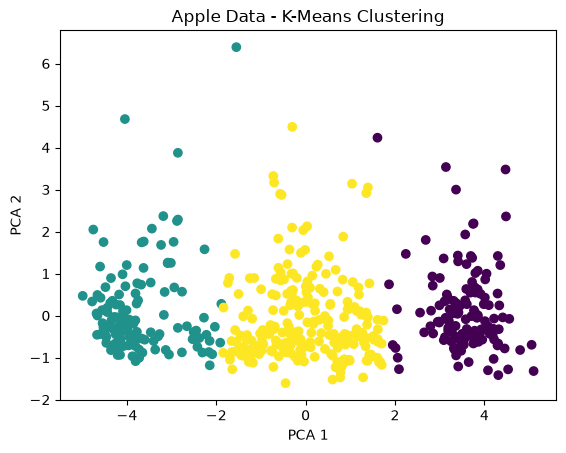

Cluster 0: ['2016', '08', '05', '11', '03', '12', '09', '10', '06', '02']
Cluster 1: ['2015', '10', '06', '08', '03', '09', '04', '12', '11', '07']
Cluster 2: ['01', '2017', '2016', '02', '06', '2015', '07', '04', '12', '09']
Done!


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5027/153357212.py:40: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


In [1]:
# Install if needed:
# !pip install pandas numpy matplotlib scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# 1. Load dataset
df = pd.read_csv("finance-charts-apple.csv")
print(df.head())
print(df.columns)

# 2. K-Means on numerical data
num_cols = df.select_dtypes(include=np.number).columns
X = df[num_cols].fillna(df[num_cols].median())

X = StandardScaler().fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# 3. Visualize K-Means clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Apple Data - K-Means Clustering")
plt.show()

# 4. NLP
# Automatically select the first text column
text_cols = df.select_dtypes(include="object").columns

if len(text_cols) > 0:
    text_col = text_cols[0]
    text = df[text_col].fillna("").astype(str)

    tfidf = TfidfVectorizer(stop_words="english", max_features=500)
    X_text = tfidf.fit_transform(text)

    # NLP K-Means
    text_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df["NLP_Cluster"] = text_kmeans.fit_predict(X_text)

    # Display important words
    words = tfidf.get_feature_names_out()
    for i, center in enumerate(text_kmeans.cluster_centers_):
        top = center.argsort()[-10:][::-1]
        print(f"Cluster {i}:", [words[j] for j in top])

# 5. Save result
df.to_csv("apple_kmeans_nlp.csv", index=False)

print("Done!")